In [1]:
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import numpy as np
import h5py
#from common import smooth
from matplotlib.ticker import FormatStrFormatter

plt.rc('font', family='Times New Roman', size=14)
plt.rcParams['mathtext.fontset'] = 'custom'

plt.rcParams['mathtext.it'] = 'STIXGeneral:italic'
plt.rcParams['mathtext.rm'] = 'STIXGeneral:bold'
plt.rcParams['mathtext.tt'] = 'STIXGeneral'
plt.rcParams['mathtext.bf'] = 'STIXGeneral:bold:italic'
plt.rcParams['mathtext.cal'] = 'STIXGeneral'
plt.rcParams['mathtext.sf'] = 'STIXGeneral'

plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 1.5

itr = r'$R$'
ite = r'$E$'

color_dict = {'HF':'tab:gray',
              'CASSCF':'tab:gray',
              'GW':'tab:red',
              'FCI':'black'}

color_dict = {'HF':'C1',
              'CASSCF':'C0',
              'GW0':'tab:green',
              'GW1':'tab:purple',
              'GW2':'tab:orange',
              'FCI':'black'}

In [2]:
from pyscf.data.nist import HARTREE2EV as au2ev
import numpy as np

theta = np.array( range(90,150,4) )

e0_ccsd = np.array([-224.4879461087393, -224.5164324855662, -224.537982082383, -224.5539098617323, -224.5652276441176, -224.5727170367964, -224.5769861995745, -224.5785130252447, -224.5776778981207, -224.5747886419877, -224.5700999676527, -224.5638292998908, -224.5561707040865, -224.5473073315798, -224.5374259193803])#, -224.526732074296])
e0_ccsdt = e0_ccsd + np.array([-0.0285033569524188, -0.0278415230219931, -0.0273803232073081, -0.0270590616729853, -0.0268369561333065, -0.026685379678959, -0.0265831894866606, -0.0265136793593173, -0.0264625246373813, -0.0264164908188358, -0.0263625507489167, -0.026287334877353, -0.0261768520007297, -0.0260161740169881, -0.0257902570973015])#, -0.0254844808666056])

ip_ccsd_a1 = np.array([0.5046528901, 0.4970658709, 0.4896490610, 0.4824107202, 0.4753199422, 0.4683351779, 0.4614151232, 0.4545203594, 0.4476145681, 0.4406627587, 0.4336323129, 0.4264946233, 0.4192288213, 0.4118303715, 0.4043052455])#, 0.3966966740])
ip_ccsd_a2 = np.array([0.4704686428, 0.4755646986, 0.4798470229, 0.4834008919, 0.4863116773, 0.4886554088, 0.4905035289, 0.4919250053, 0.4929774723, 0.4937113883, 0.4941687067, 0.4943831464, 0.4943820550, 0.4941886511, 0.4938220244])#, 0.4933034214])
ip_ccsd_b2 = np.array([0.3980095824, 0.4138063272, 0.4269449598, 0.4378699199, 0.4469451441, 0.4544688067, 0.4606863340, 0.4658004916, 0.4699791220, 0.4733608492, 0.4760598257, 0.4781702093, 0.4797708235, 0.4809300057, 0.4817104638])#, 0.4821747217])

ip_mrgw64_a1 = np.array([14.0000000000, 13.8000000000, 13.6000000000, 13.3900000000, 13.1900000000, 12.9900000000, 12.8000000000, 12.5900000000, 12.3800000000, 12.1800000000, 11.9700000000, 11.7600000000, 11.5400000000, 11.3300000000, 11.1000000000])/au2ev#, 10.8900000000])/au2ev
ip_mrgw64_b2 = np.array([11.4600000000, 11.8300000000, 12.1400000000, 12.3800000000, 12.5800000000, 12.7400000000, 12.8600000000, 12.9600000000, 13.0300000000, 13.0800000000, 13.1000000000, 13.1100000000, 13.0900000000, 13.0700000000, 13.0200000000])/au2ev#, 12.9600000000])
ip_mrgw64_a2 = np.array([14.1100000000, 14.2300000000, 14.3200000000, 14.4000000000, 14.4600000000, 14.5100000000, 14.5400000000, 14.5600000000, 14.5800000000, 14.5800000000, 14.5700000000, 14.5500000000, 14.5200000000, 14.4900000000, 14.4400000000])/au2ev

ip_mrgw85_a1 = np.array([12.3100000000, 12.3100000000, 12.2500000000, 12.1500000000, 12.0200000000, 11.8600000000, 11.7100000000, 11.5300000000, 11.3400000000, 11.1400000000, 10.9300000000, 10.7100000000, 10.4800000000, 10.2400000000, 10.0000000000])/au2ev
ip_mrgw85_b2 = np.array([10.7000000000, 11.0700000000, 11.3700000000, 11.6000000000, 11.7900000000, 11.9300000000, 12.0400000000, 12.1100000000, 12.1500000000, 12.1700000000, 12.1600000000, 12.1300000000, 12.0800000000, 12.0100000000, 11.9200000000])/au2ev
ip_mrgw85_a2 = np.array([12.4600000000, 12.5900000000, 12.7000000000, 12.7800000000, 12.8500000000, 12.8900000000, 12.9200000000, 12.9400000000, 12.9500000000, 12.9400000000, 12.9300000000, 12.9100000000, 12.8800000000, 12.8400000000, 12.7900000000])/au2ev

ip_cas86_a1 = np.array([14.1602554911, 14.2422659961, 14.2420464195, 14.1899368857, 14.1044178564, 13.9963629323, 13.8719980833, 13.7347447348, 13.5863270560, 13.4274443698, 13.2582008376, 13.0784074482, 12.8878247010, 12.6863868963, 12.4744848057])/au2ev#, 12.2532610891])/au2ev
ip_cas86_b2 = np.array([12.7142975700, 13.0626021145, 13.3461165000, 13.5768297315, 13.7639578349, 13.9145823621, 14.0340910173, 14.1264929393, 14.1946529710, 14.2404686482, 14.2650022282, 14.2685782257, 14.2508632619, 14.2109613391, 14.1475512749])/au2ev#, 14.0592304973])/au2ev
ip_cas86_a2 = np.array([12.8184518682, 12.9296505155, 13.0236807972, 13.1020694681, 13.1664066723, 13.2182347055, 13.2589556487, 13.2897688480, 13.3116374694, 13.3252766899, 13.3311536980, 13.3294906158, 13.3202642378, 13.3032003591, 13.2777624399])/au2ev#, 13.2431593542])/au2ev

#ip_mrgw86_a1 = np.array([13.3400000000, 12.5700000000, 12.5100000000, 12.4200000000, 12.3000000000, 12.1600000000, 12.0300000000, 11.8800000000, 11.7200000000, 11.5400000000, 11.3600000000, 11.1700000000, 10.9700000000, 10.7500000000, 10.5200000000])/au2ev
ip_mrgw86_a1 = np.array([12.5700000000, 12.5700000000, 12.5100000000, 12.4200000000, 12.3000000000, 12.1600000000, 12.0300000000, 11.8800000000, 11.7200000000, 11.5400000000, 11.3600000000, 11.1700000000, 10.9700000000, 10.7500000000, 10.5200000000])/au2ev
ip_mrgw86_b2 = np.array([10.8100000000, 11.1800000000, 11.4800000000, 11.7400000000, 11.9400000000, 12.1300000000, 12.2500000000, 12.3600000000, 12.4400000000, 12.5000000000, 12.5400000000, 12.5600000000, 12.5500000000, 12.5300000000, 12.4700000000])/au2ev
ip_mrgw86_a2 = np.array([12.5700000000, 12.7000000000, 12.8100000000, 12.9000000000, 12.9700000000, 13.0200000000, 13.0600000000, 13.0900000000, 13.1100000000, 13.1200000000, 13.1200000000, 13.1200000000, 13.1000000000, 13.0700000000, 13.0400000000])/au2ev

ip_srgw_a1 = np.array([14.7247308088, 14.4660878974, 14.2262778382, 14.0013285770, 13.7876749032, 13.5822957021, 13.3826891498, 13.1867818648, 12.9928307950, 12.7993555786, 12.6051224250, 12.4091874555, 12.2109975055, 12.0105364191, 11.8085771253])/au2ev#, 11.6068979106])/au2ev
ip_srgw_b2 = np.array([11.6377181178, 12.0848920819, 12.4582911861, 12.7707907389, 13.0328472092, 13.2529754768, 13.4381451197, 13.5940926231, 13.7255576380, 13.8364591050, 13.9300314161, 14.0089377238, 14.0753710812, 14.1311659367, 14.1777496165])/au2ev#, 14.2162798896])/au2ev
ip_srgw_a2 = np.array([12.5528936640, 12.6989750573, 12.8241969147, 12.9308595830, 13.0211759923, 13.0972305871, 13.1609486085, 13.2140653157, 13.2580954857, 13.2943112383, 13.3237372911, 13.3471678963, 13.3652016428, 13.3782743794, 13.3867709628])/au2ev#, 13.3910407303])/au2ev

ip_kt_a1 = -np.array([-0.619761449271716, -0.608653701342267, -0.598772922210894, -0.589848378830699, -0.581658380969988, -0.574022995006905, -0.56679720249488, -0.559864595095496, -0.553132097153839, -0.546526274956551, -0.539991584203316, -0.53349061858814, -0.527006110946976, -0.520544073876354, -0.514139954679231])#, -0.507861436470858])
ip_kt_b2 = -np.array([-0.510947259214513, -0.52697109684053, -0.540282801386546, -0.551378927501827, -0.560660080152632, -0.568452840251447, -0.57502702232806, -0.580608975009564, -0.585391526837289, -0.589541279297201, -0.59320408150514, -0.596509346484591, -0.599573537071805, -0.602503933830421, -0.605390802159481])#, -0.60830922850632])
ip_kt_a2 = -np.array([-0.476197282130788, -0.480187908513577, -0.483719760396288, -0.486836227493206, -0.489586256404906, -0.492020933687446, -0.494190991469713, -0.496144520364297, -0.497924751568545, -0.499568171845313, -0.501103299745178, -0.502550238068245, -0.503920684846578, -0.505216634413436, -0.506436109604324])#, -0.507567756416211])


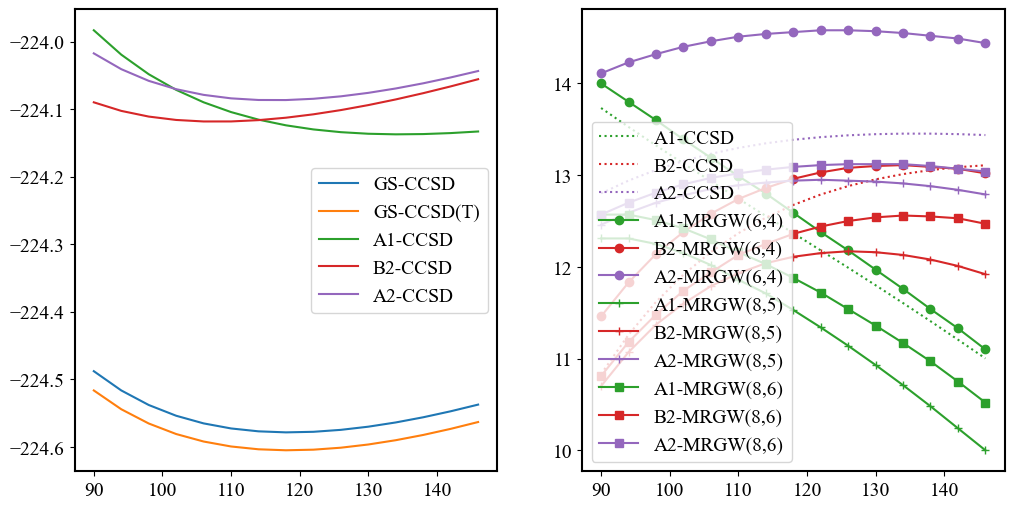

In [17]:
fig, (ax1,ax2) = plt.subplots(ncols=2, nrows=1, figsize=(12,6))

ax1.plot(theta, e0_ccsd, color='C0', label='GS-CCSD')
ax1.plot(theta, e0_ccsdt, color='C1', label='GS-CCSD(T)')
ax1.plot(theta, e0_ccsd+ip_ccsd_a1, color='C2', label='A1-CCSD')
ax1.plot(theta, e0_ccsd+ip_ccsd_b2, color='C3', label='B2-CCSD')
ax1.plot(theta, e0_ccsd+ip_ccsd_a2, color='C4', label='A2-CCSD')
ax1.legend()

ax2.plot(theta, ip_ccsd_a1*au2ev, label='A1-CCSD', color='C2', ls='dotted')
ax2.plot(theta, ip_ccsd_b2*au2ev, label='B2-CCSD', color='C3', ls='dotted')
ax2.plot(theta, ip_ccsd_a2*au2ev, label='A2-CCSD', color='C4', ls='dotted')
ax2.plot(theta, ip_mrgw64_a1*au2ev, label='A1-MRGW(6,4)', color='C2', marker='o')
ax2.plot(theta, ip_mrgw64_b2*au2ev, label='B2-MRGW(6,4)', color='C3', marker='o')
ax2.plot(theta, ip_mrgw64_a2*au2ev, label='A2-MRGW(6,4)', color='C4', marker='o')

ax2.plot(theta, ip_mrgw85_a1*au2ev, label='A1-MRGW(8,5)', color='C2', marker='+')
ax2.plot(theta, ip_mrgw85_b2*au2ev, label='B2-MRGW(8,5)', color='C3', marker='+')
ax2.plot(theta, ip_mrgw85_a2*au2ev, label='A2-MRGW(8,5)', color='C4', marker='+')

ax2.plot(theta, ip_mrgw86_a1*au2ev, label='A1-MRGW(8,6)', color='C2', marker='s')
ax2.plot(theta, ip_mrgw86_b2*au2ev, label='B2-MRGW(8,6)', color='C3', marker='s')
ax2.plot(theta, ip_mrgw86_a2*au2ev, label='A2-MRGW(8,6)', color='C4', marker='s')

ax2.legend()

In [3]:
e0_dmrg_a1 = np.array([-224.523581535518275, -224.550899800306496, -224.571623630287633, -224.586963003538983, -224.597847781650074, -224.605014215404481, -224.609045801391915, -224.610384048080988, -224.609275082263480, -224.606395952446121, -224.601649421663211, -224.595308155747944, -224.587603614939837, -224.578575454761790, -224.568471458811757])#, -224.557538218631464])
ei_dmrg_a1 = np.array([-224.052337691318229, -224.073443510265434, -224.094724541037834, -224.113390699637591, -224.128943942744314, -224.141514444615609, -224.151410459426074, -224.158910191926367, -224.164186413272887, -224.167986523881211, -224.170074307355293, -224.170774354331797, -224.170335174578838, -224.168707129879976, -224.166170400418480])


#ei_dmrg_b2 = np.array([-224.119602499269121, -224.132511599458979, -224.141300690009729, -224.146822213417408, -224.149625342560768, -224.150178126491880, -224.148895026282560, -224.145966408821579, -224.141328893974844, -224.136384474758529, -224.130119880201988, -224.122927720317193, -224.115208585471805, -224.106551035639768, -224.097586548201718])#, -224.088696224929265])

ei_dmrg_b2 = np.array([-224.119960113031055, -224.132879833362296, -224.141678339373840, -224.147194308291716, -224.150022304084615, -224.150631847976797, -224.149404679775159, -224.146576677360343, -224.142233699916630, -224.137136295200378, -224.130877485759896, -224.123726575075523, -224.115928931604856, -224.107408068744519, -224.098547578623482])#, -224.089624945899175])


#ei_dmrg_a2 = np.array([-224.050121507268699, -224.073489781729592, -224.090817398260214, -224.103282919576714, -224.111770097678090, -224.117203470271818, -224.119440108525168, -224.119558751460914, -224.117429302433891, -224.114086114038571, -224.109036149588604, -224.102601894974384, -224.095130320988119, -224.086421707853560, -224.076940797329428])#, -224.067464141713231])
                                                                                                                                      # -224.075834350816251
ei_dmrg_a2 = np.array([-224.050359577245132, -224.073706298703456, -224.091026015893959, -224.103484518075163, -224.111978261561859, -224.117157640389223, -224.119702092911098, -224.119866963391331, -224.117922252635083, -224.114482658252996, -224.109430773170089, -224.103021472607793, -224.095494342377549, -224.086881779068733, -224.077549791719434])#, -224.068310305251032])


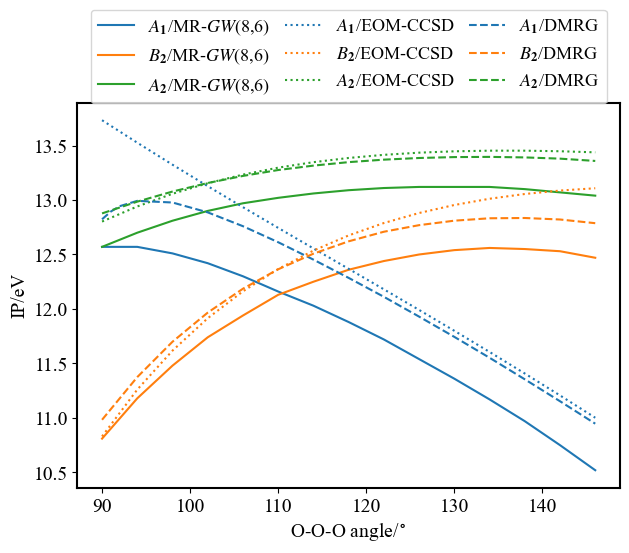

In [4]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(7,5))


#ax.plot(theta, ip_mrgw64_a1*au2ev, label='A1-MRGW(6,4)', color='C2', marker='o')
#ax.plot(theta, ip_mrgw64_b2*au2ev, label='B2-MRGW(6,4)', color='C3', marker='o')
#ax.plot(theta, ip_mrgw64_a2*au2ev, label='A2-MRGW(6,4)', color='C4', marker='o')

#ax.plot(theta, ip_mrgw85_a1*au2ev, label='A1-MRGW(8,5)', color='C2', marker='+')
#ax.plot(theta, ip_mrgw85_b2*au2ev, label='B2-MRGW(8,5)', color='C3', marker='+')
#ax.plot(theta, ip_mrgw85_a2*au2ev, label='A2-MRGW(8,5)', color='C4', marker='+')

x = theta; y = ip_mrgw86_a1*au2ev
ax.plot(x, y, label=r'$A_1$/MR-$GW$(8,6)', color='C0', ls='-')
x = theta; y = ip_mrgw86_b2*au2ev
ax.plot(x, y, label=r'$B_2$/MR-$GW$(8,6)', color='C1', ls='-')
x = theta; y = ip_mrgw86_a2*au2ev
ax.plot(x, y, label=r'$A_2$/MR-$GW$(8,6)', color='C2', ls='-')


x = theta; y = ip_ccsd_a1*au2ev
ax.plot(x, y, label=r'$A_1$/EOM-CCSD', color='C0', ls='dotted')
x = theta; y = ip_ccsd_b2 * au2ev
ax.plot(x, y, label=r'$B_2$/EOM-CCSD', color='C1', ls='dotted')
x = theta; y = ip_ccsd_a2 * au2ev
ax.plot(x, y, label=r'$A_2$/EOM-CCSD', color='C2', ls='dotted')
#idx = np.where(theta2 > 89)[0]

#ax.plot(theta2[idx], (ei_dmrg_a1[idx] - e0_dmrg_a1[idx])*au2ev, label='A1-DMRG', color='C2', marker='o')
#ax.plot(theta2[idx], (ei_dmrg_b2[idx] - e0_dmrg_a1[idx])*au2ev, label='B2-DMRG', color='C2', marker='s')
#ax.plot(theta2[idx], (ei_dmrg_a2[idx] - e0_dmrg_a1[idx])*au2ev, label='A2-DMRG', color='C2', marker='d')

x = theta; y = (ei_dmrg_a1 - e0_dmrg_a1)*au2ev
x = [theta[0]] + [91,92] + list(theta[1:])
y = [y[0]] + [(-224.057248563068043+224.531107003756432)*au2ev, (-224.062493757974352+224.538152469312735)*au2ev] + list(y[1:])
ax.plot(x, y, label=r'$A_1$/DMRG', color='C0', ls='--')
x = theta; y = (ei_dmrg_b2 - e0_dmrg_a1)*au2ev
ax.plot(x, y, label=r'$B_2$/DMRG', color='C1', ls='--')
x = theta; y = (ei_dmrg_a2 - e0_dmrg_a1)*au2ev
ax.plot(x, y, label=r'$A_2$/DMRG', color='C2', ls='--')


ax.set_xlabel(r'O-O-O angle/$^\circ$')
ax.set_ylabel('IP/eV')

ax.legend(loc='center', bbox_to_anchor=(.5,1.12), ncols=3, columnspacing=.8, fontsize=13)

plt.savefig('o3-bending-ip.pdf', format='pdf', bbox_inches='tight')

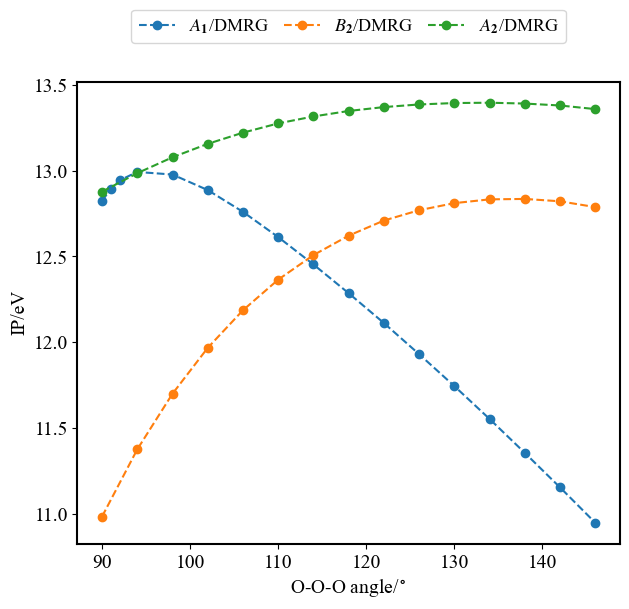

In [20]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(7,6))


#ax.plot(theta, ip_mrgw64_a1*au2ev, label='A1-MRGW(6,4)', color='C2', marker='o')
#ax.plot(theta, ip_mrgw64_b2*au2ev, label='B2-MRGW(6,4)', color='C3', marker='o')
#ax.plot(theta, ip_mrgw64_a2*au2ev, label='A2-MRGW(6,4)', color='C4', marker='o')

#ax.plot(theta, ip_mrgw85_a1*au2ev, label='A1-MRGW(8,5)', color='C2', marker='+')
#ax.plot(theta, ip_mrgw85_b2*au2ev, label='B2-MRGW(8,5)', color='C3', marker='+')
#ax.plot(theta, ip_mrgw85_a2*au2ev, label='A2-MRGW(8,5)', color='C4', marker='+')

#x = theta; y = ip_mrgw86_a1*au2ev
#ax.plot(x, y, label=r'$A_1$/MR-$GW$(8,6)', color='C0', ls='-')
#x = theta; y = ip_mrgw86_b2*au2ev
#ax.plot(x, y, label=r'$B_2$/MR-$GW$(8,6)', color='C1', ls='-')
#x = theta; y = ip_mrgw86_a2*au2ev
#ax.plot(x, y, label=r'$A_2$/MR-$GW$(8,6)', color='C2', ls='-')


#x = theta; y = ip_ccsd_a1*au2ev
#ax.plot(x, y, label=r'$A_1$/EOM-CCSD', color='C0', ls='dotted')
#x = theta; y = ip_ccsd_b2 * au2ev
#ax.plot(x, y, label=r'$B_2$/EOM-CCSD', color='C1', ls='dotted')
#x = theta; y = ip_ccsd_a2 * au2ev
#ax.plot(x, y, label=r'$A_2$/EOM-CCSD', color='C2', ls='dotted')
#idx = np.where(theta2 > 89)[0]

#ax.plot(theta2[idx], (ei_dmrg_a1[idx] - e0_dmrg_a1[idx])*au2ev, label='A1-DMRG', color='C2', marker='o')
#ax.plot(theta2[idx], (ei_dmrg_b2[idx] - e0_dmrg_a1[idx])*au2ev, label='B2-DMRG', color='C2', marker='s')
#ax.plot(theta2[idx], (ei_dmrg_a2[idx] - e0_dmrg_a1[idx])*au2ev, label='A2-DMRG', color='C2', marker='d')

x = theta; y = (ei_dmrg_a1 - e0_dmrg_a1)*au2ev
x = [theta[0]] + [91,92] + list(theta[1:])
y = [y[0]] + [(-224.057248563068043+224.531107003756432)*au2ev, (-224.062493757974352+224.538152469312735)*au2ev] + list(y[1:])
ax.plot(x, y, label=r'$A_1$/DMRG', color='C0', ls='--', marker='o')
x = theta; y = (ei_dmrg_b2 - e0_dmrg_a1)*au2ev
ax.plot(x, y, label=r'$B_2$/DMRG', color='C1', ls='--', marker='o')
x = theta; y = (ei_dmrg_a2 - e0_dmrg_a1)*au2ev
ax.plot(x, y, label=r'$A_2$/DMRG', color='C2', ls='--', marker='o')


ax.set_xlabel(r'O-O-O angle/$^\circ$')
ax.set_ylabel('IP/eV')

ax.legend(loc='center', bbox_to_anchor=(.5,1.12), ncols=3, columnspacing=.8, fontsize=13)

#plt.savefig('o3-bending-ip.pdf', format='pdf', bbox_inches='tight')

In [7]:
casci129 = np.array([0.875788783086, 0.882189526650, 0.886916752885, 0.890440513401, 0.893032659220, 0.894882903290, 0.896112262888, 0.896799982303, 0.896998869804, 0.896745702149, 0.896069394234, 0.895001353385, 0.893581705606, 0.891882969824, 0.890046027975, 0.888318528290])
casci86 = np.array([0.905323907723, 0.908980291606, 0.912048766406, 0.914648710492, 0.916866351826, 0.918760675135, 0.920370204241, 0.921719148100, 0.922822539783, 0.923690408634, 0.924331373049, 0.924756482800, 0.924984531968, 0.925049798460, 0.925018248836, 0.925006197864])
casci64 = np.array([0.920210539246, 0.923420949972, 0.926226344659, 0.928727219217, 0.931001301179, 0.933108486747, 0.935094506038, 0.936993418914, 0.938828989956, 0.940615019513, 0.942354571228, 0.944037772256, 0.945637381940, 0.947099704391, 0.948334771271, 0.949187428008])

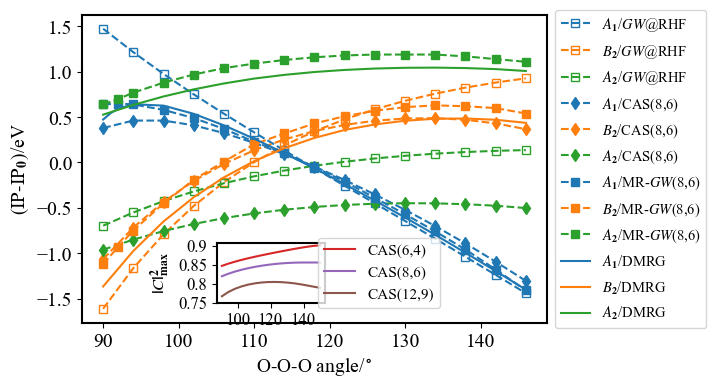

In [22]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6,4))


#ax.plot(theta, ip_mrgw64_a1*au2ev, label='A1-MRGW(6,4)', color='C2', marker='o')
#ax.plot(theta, ip_mrgw64_b2*au2ev, label='B2-MRGW(6,4)', color='C3', marker='o')
#ax.plot(theta, ip_mrgw64_a2*au2ev, label='A2-MRGW(6,4)', color='C4', marker='o')

#ax.plot(theta, ip_mrgw85_a1*au2ev, label='A1-MRGW(8,5)', color='C2', marker='+')
#ax.plot(theta, ip_mrgw85_b2*au2ev, label='B2-MRGW(8,5)', color='C3', marker='+')
#ax.plot(theta, ip_mrgw85_a2*au2ev, label='A2-MRGW(8,5)', color='C4', marker='+')

# ---- Koopmans ----
y0_a1 = 15.29 
y0_b2 = y0_a1#13.52 
y0_a2 = y0_a1#13.20
x = theta; y = ip_kt_a1*au2ev
#ax.plot(x, y-y0_a1, label=r'$A_1$/Koopmans', color='C0', ls='--', marker='d', mfc='none')
x = theta; y = ip_kt_b2*au2ev
#ax.plot(x, y-y0_b2, label=r'$B_2$/Koopmans', color='C1', ls='--', marker='d', mfc='none')
x = theta; y = ip_kt_a2*au2ev
#ax.plot(x, y-y0_a2, label=r'$A_2$/Koopmans', color='C2', ls='--', marker='d', mfc='none')

# ---- SR-GW ----

y0_a1 = 13.25  
y0_b2 = y0_a1#13.52 
y0_a2 = y0_a1#13.20
x = np.asarray(x); y = ip_srgw_a1*au2ev
ax.plot(x, y-y0_a1, label=r'$A_1$/$GW$@RHF', color='C0', ls='--', marker='s', mfc='none')
x = theta; y = ip_srgw_b2*au2ev
ax.plot(x, y-y0_b2, label=r'$B_2$/$GW$@RHF', color='C1', ls='--', marker='s', mfc='none')
x = theta; y = ip_srgw_a2*au2ev
ax.plot(x, y-y0_a2, label=r'$A_2$/$GW$@RHF', color='C2', ls='--', marker='s', mfc='none')

# ---- CAS(8,6) ----

y0 = 13.78
x = np.asarray(theta); y = ip_cas86_a1*au2ev
ax.plot(x, y-y0, label=r'$A_1$/CAS(8,6)', color='C0', ls='--', marker='d')
x = theta; y = ip_cas86_b2*au2ev
ax.plot(x, y-y0, label=r'$B_2$/CAS(8,6)', color='C1', ls='--', marker='d')
x = theta; y = ip_cas86_a2*au2ev
ax.plot(x, y-y0, label=r'$A_2$/CAS(8,6)', color='C2', ls='--', marker='d')

# ---- MRGW(8,6) ----

y0_a1 = 11.93
y0_b2 = y0_a1#12.33
y0_a2 = y0_a1#13.09

x = np.insert(theta,1,92)
y = np.insert(ip_mrgw86_a1,1,12.58/au2ev)*au2ev 
ax.plot(x, y-y0_a1, label=r'$A_1$/MR-$GW$(8,6)', color='C0', ls='--', marker='s')
x = np.insert(theta,1,92)
y = np.insert(ip_mrgw86_b2,1,11.00/au2ev)*au2ev 
ax.plot(x, y-y0_b2, label=r'$B_2$/MR-$GW$(8,6)', color='C1', ls='--', marker='s')
x = np.insert(theta,1,92)
y = np.insert(ip_mrgw86_a2,1,12.63/au2ev)*au2ev 
ax.plot(x, y-y0_a2, label=r'$A_2$/MR-$GW$(8,6)', color='C2', ls='--', marker='s')

# ---- EOM-CCSD ----

y0_a1 = 12.42  
y0_b2 = y0_a1#12.64   
y0_a2 = y0_a1#13.38 

x = theta; y = ip_ccsd_a1*au2ev
#ax.plot(x, y-y0_a1, label=r'$A_1$/EOM-CCSD', color='C0', ls='--', marker='o', mfc='none')
x = theta; y = ip_ccsd_b2 * au2ev
#ax.plot(x, y-y0_b2, label=r'$B_2$/EOM-CCSD', color='C1', ls='--', marker='o', mfc='none')
x = theta; y = ip_ccsd_a2 * au2ev
#ax.plot(x, y-y0_a2, label=r'$A_2$/EOM-CCSD', color='C2', ls='--', marker='o', mfc='none')

#idx = np.where(theta2 > 89)[0]

#ax.plot(theta2[idx], (ei_dmrg_a1[idx] - e0_dmrg_a1[idx])*au2ev, label='A1-DMRG', color='C2', marker='o')
#ax.plot(theta2[idx], (ei_dmrg_b2[idx] - e0_dmrg_a1[idx])*au2ev, label='B2-DMRG', color='C2', marker='s')
#ax.plot(theta2[idx], (ei_dmrg_a2[idx] - e0_dmrg_a1[idx])*au2ev, label='A2-DMRG', color='C2', marker='d')

# ---- DMRG ---

y0_a1 = 12.35 
y0_b2 = y0_a1#12.61
y0_a2 = y0_a1#13.35

x = theta; y = (ei_dmrg_a1 - e0_dmrg_a1)*au2ev
x = [theta[0]] + [91,92] + list(theta[1:])
y = [y[0]] + [(-224.057248563068043+224.531107003756432)*au2ev, (-224.062493757974352+224.538152469312735)*au2ev] + list(y[1:])
x = np.asarray(x); y = np.asarray(y)
ax.plot(x, y-y0_a1, label=r'$A_1$/DMRG', color='C0', ls='-')
x = theta; y = (ei_dmrg_b2 - e0_dmrg_a1)*au2ev
ax.plot(x, y-y0_b2, label=r'$B_2$/DMRG', color='C1', ls='-')
x = theta; y = (ei_dmrg_a2 - e0_dmrg_a1)*au2ev
ax.plot(x, y-y0_a2, label=r'$A_2$/DMRG', color='C2', ls='-')

ax.set_xlabel(r'O-O-O angle/$^\circ$')
ax.set_ylabel(r'(IP-IP$_0$)/eV')

ax1s = fig.add_axes((.35,.16,.18,.15))

ax1s.plot(np.array( range(90,151,4) ), casci64**2, label='CAS(6,4)', color='C3')
ax1s.plot(np.array( range(90,151,4) ), casci86**2, label='CAS(8,6)', color='C4')
ax1s.plot(np.array( range(90,151,4) ), casci129**2, label='CAS(12,9)', color='C5')
ax1s.set_ylabel(r'$|C|^2_\text{max}$', fontsize=12)
ax1s.legend(loc='center', bbox_to_anchor=(1.5,.5), fontsize=11) 

yt = [.75, .8, .85, .9]
ax1s.set_yticks(yt)
ax1s.set_yticklabels(yt, fontsize=12)

xt = [100,120,140]
ax1s.set_xticks(xt)
ax1s.set_xticklabels(xt, fontsize=12)
#ax.set_xlabel(r'O-O-O angle/$^\circ$')

ax.legend(loc='center', bbox_to_anchor=(1.18,.5), ncols=1, fontsize=10.5, labelspacing=.6)

plt.savefig('o3-bending-ip.pdf', format='pdf', bbox_inches='tight')

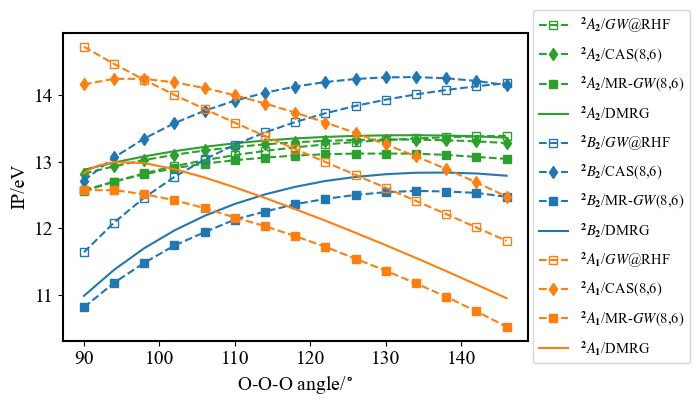

In [14]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6,4))

# ---- Koopmans ----
y0_a1 = 0#15.29 
y0_b2 = y0_a1#13.52 
y0_a2 = y0_a1#13.20
x = theta; y = ip_kt_a1*au2ev
#ax.plot(x, y-y0_a1, label=r'$A_1$/Koopmans', color='C0', ls='--', marker='d', mfc='none')
x = theta; y = ip_kt_b2*au2ev
#ax.plot(x, y-y0_b2, label=r'$B_2$/Koopmans', color='C1', ls='--', marker='d', mfc='none')
x = theta; y = ip_kt_a2*au2ev
#ax.plot(x, y-y0_a2, label=r'$A_2$/Koopmans', color='C2', ls='--', marker='d', mfc='none')

# ---- SR-GW ----

y0_a1 = 0#13.25  
y0_b2 = y0_a1#13.52 
y0_a2 = y0_a1#13.20
x = theta; y = ip_srgw_a2*au2ev
ax.plot(x, y, label=r'$^2A_2$/$GW$@RHF', color='C2', ls='--', marker='s', mfc='none')
x = theta; y = ip_cas86_a2*au2ev
ax.plot(x, y, label=r'$^2A_2$/CAS(8,6)', color='C2', ls='--', marker='d')
x = theta; y = ip_mrgw86_a2*au2ev 
ax.plot(x, y, label=r'$^2A_2$/MR-$GW$(8,6)', color='C2', ls='--', marker='s')
x = theta; y = (ei_dmrg_a2 - e0_dmrg_a1)*au2ev
ax.plot(x, y, label=r'$^2A_2$/DMRG', color='C2', ls='-')


x = theta; y = ip_srgw_b2*au2ev
ax.plot(x, y, label=r'$^2B_2$/$GW$@RHF', color='C0', ls='--', marker='s', mfc='none')
x = theta; y = ip_cas86_b2*au2ev
ax.plot(x, y, label=r'$^2B_2$/CAS(8,6)', color='C0', ls='--', marker='d')
x = theta; y = ip_mrgw86_b2*au2ev
ax.plot(x, y, label=r'$^2B_2$/MR-$GW$(8,6)', color='C0', ls='--', marker='s')
x = theta; y = (ei_dmrg_b2 - e0_dmrg_a1)*au2ev
ax.plot(x, y, label=r'$^2B_2$/DMRG', color='C0', ls='-')


x = np.asarray(x); y = ip_srgw_a1*au2ev
ax.plot(x, y, label=r'$^2A_1$/$GW$@RHF', color='C1', ls='--', marker='s', mfc='none')
x = np.asarray(theta); y = ip_cas86_a1*au2ev
ax.plot(x, y, label=r'$^2A_1$/CAS(8,6)', color='C1', ls='--', marker='d')
x = theta; y = ip_mrgw86_a1*au2ev
ax.plot(x, y, label=r'$^2A_1$/MR-$GW$(8,6)', color='C1', ls='--', marker='s')
x = theta; y = (ei_dmrg_a1 - e0_dmrg_a1)*au2ev
x = [theta[0]] + [91,92] + list(theta[1:])
y = [y[0]] + [(-224.057248563068043+224.531107003756432)*au2ev, (-224.062493757974352+224.538152469312735)*au2ev] + list(y[1:])
x = np.asarray(x); y = np.asarray(y)
ax.plot(x, y-y0_a1, label=r'$^2A_1$/DMRG', color='C1', ls='-')


# ---- MRGW(8,6) ----

y0_a1 = 0#11.93
y0_b2 = y0_a1#12.33
y0_a2 = y0_a1#13.09

#x = np.insert(theta,1,92)
#y = np.insert(ip_mrgw86_a1,1,12.58/au2ev)*au2ev 
#x = np.insert(theta,1,92)
#y = np.insert(ip_mrgw86_b2,1,11.00/au2ev)*au2ev


#x = np.insert(theta,1,92)
#y = np.insert(ip_mrgw86_a2,1,12.63/au2ev)*au2ev




# ---- EOM-CCSD ----

y0_a1 = 0#12.42  
y0_b2 = y0_a1#12.64   
y0_a2 = y0_a1#13.38 

x = theta; y = ip_ccsd_a1*au2ev
#ax.plot(x, y-y0_a1, label=r'$A_1$/EOM-CCSD', color='C0', ls='--', marker='o', mfc='none')
x = theta; y = ip_ccsd_b2 * au2ev
#ax.plot(x, y-y0_b2, label=r'$B_2$/EOM-CCSD', color='C1', ls='--', marker='o', mfc='none')
x = theta; y = ip_ccsd_a2 * au2ev
#ax.plot(x, y-y0_a2, label=r'$A_2$/EOM-CCSD', color='C2', ls='--', marker='o', mfc='none')

#idx = np.where(theta2 > 89)[0]

#ax.plot(theta2[idx], (ei_dmrg_a1[idx] - e0_dmrg_a1[idx])*au2ev, label='A1-DMRG', color='C2', marker='o')
#ax.plot(theta2[idx], (ei_dmrg_b2[idx] - e0_dmrg_a1[idx])*au2ev, label='B2-DMRG', color='C2', marker='s')
#ax.plot(theta2[idx], (ei_dmrg_a2[idx] - e0_dmrg_a1[idx])*au2ev, label='A2-DMRG', color='C2', marker='d')

# ---- DMRG ---

y0_a1 = 0#12.35 
y0_b2 = y0_a1#12.61
y0_a2 = y0_a1#13.35




ax.set_xlabel(r'O-O-O angle/$^\circ$')
ax.set_ylabel(r'IP/eV')

#ax1s = fig.add_axes((.32,.15,.18,.15))

#ax1s.plot(np.array( range(90,151,4) ), casci64**2, label='CAS(6,4)', color='C3')
#ax1s.plot(np.array( range(90,151,4) ), casci86**2, label='CAS(8,6)', color='C4')
#ax1s.plot(np.array( range(90,151,4) ), casci129**2, label='CAS(12,9)', color='C5')
#ax1s.set_ylabel(r'$|C|^2_\text{max}$', fontsize=12)
#ax1s.legend(loc='center', bbox_to_anchor=(1.5,.4), fontsize=11) 

#yt = [.75, .8, .85, .9]
#ax1s.set_yticks(yt)
#ax1s.set_yticklabels(yt, fontsize=12)

#xt = [100,120,140]
#ax1s.set_xticks(xt)
#ax1s.set_xticklabels(xt, fontsize=12)
#ax.set_xlabel(r'O-O-O angle/$^\circ$')

ax.legend(loc='center', bbox_to_anchor=(1.18,.5), ncols=1, columnspacing=.8, fontsize=10.5, labelspacing=.7)

plt.savefig('o3-bending-ip.pdf', format='pdf', bbox_inches='tight')

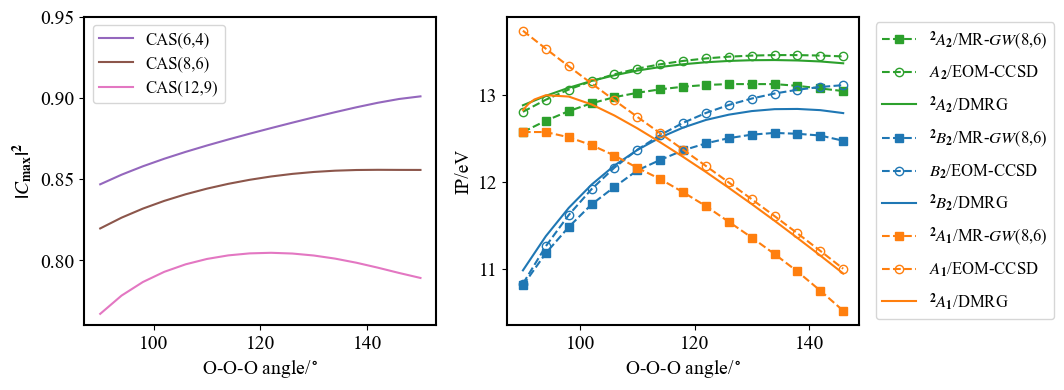

In [31]:
fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(10,4))


ax = ax1
ax.plot(np.array( range(90,151,4) ), casci64**2, label='CAS(6,4)', color='C4')
ax.plot(np.array( range(90,151,4) ), casci86**2, label='CAS(8,6)', color='C5')
ax.plot(np.array( range(90,151,4) ), casci129**2, label='CAS(12,9)', color='C6')
ax.set_ylabel(r'$|C_\text{max}|^2$')
ax.set_xlabel(r'O-O-O angle/$^\circ$')
ax.legend(fontsize=12)#(loc='center', bbox_to_anchor=(1.2,.85))
ax.set_ylim(top=.95)

ax = ax2

x = theta; y = ip_srgw_a2*au2ev
#ax.plot(x, y, label=r'$^2A_2$/$GW$@RHF', color='C2', ls='--', marker='s', mfc='none')
x = theta; y = ip_cas86_a2*au2ev
#ax.plot(x, y, label=r'$^2A_2$/CAS(8,6)', color='C2', ls='--', marker='d')
x = theta; y = ip_mrgw86_a2*au2ev 
ax.plot(x, y, label=r'$^2A_2$/MR-$GW$(8,6)', color='C2', ls='--', marker='s')
x = theta; y = ip_ccsd_a2 * au2ev
ax.plot(x, y-y0_a2, label=r'$A_2$/EOM-CCSD', color='C2', ls='--', marker='o', mfc='none')
x = theta; y = (ei_dmrg_a2 - e0_dmrg_a1)*au2ev
ax.plot(x, y, label=r'$^2A_2$/DMRG', color='C2', ls='-')


x = theta; y = ip_srgw_b2*au2ev
#ax.plot(x, y, label=r'$^2B_2$/$GW$@RHF', color='C0', ls='--', marker='s', mfc='none')
x = theta; y = ip_cas86_b2*au2ev
#ax.plot(x, y, label=r'$^2B_2$/CAS(8,6)', color='C0', ls='--', marker='d')
x = theta; y = ip_mrgw86_b2*au2ev
ax.plot(x, y, label=r'$^2B_2$/MR-$GW$(8,6)', color='C0', ls='--', marker='s')
x = theta; y = ip_ccsd_b2 * au2ev
ax.plot(x, y-y0_b2, label=r'$B_2$/EOM-CCSD', color='C0', ls='--', marker='o', mfc='none')
x = theta; y = (ei_dmrg_b2 - e0_dmrg_a1)*au2ev
ax.plot(x, y, label=r'$^2B_2$/DMRG', color='C0', ls='-')


x = np.asarray(x); y = ip_srgw_a1*au2ev
#ax.plot(x, y, label=r'$^2A_1$/$GW$@RHF', color='C1', ls='--', marker='s', mfc='none')
x = np.asarray(theta); y = ip_cas86_a1*au2ev
#ax.plot(x, y, label=r'$^2A_1$/CAS(8,6)', color='C1', ls='--', marker='d')
x = theta; y = ip_mrgw86_a1*au2ev
ax.plot(x, y, label=r'$^2A_1$/MR-$GW$(8,6)', color='C1', ls='--', marker='s')
x = theta; y = ip_ccsd_a1*au2ev
ax.plot(x, y-y0_a1, label=r'$A_1$/EOM-CCSD', color='C1', ls='--', marker='o', mfc='none')
x = theta; y = (ei_dmrg_a1 - e0_dmrg_a1)*au2ev
x = [theta[0]] + [91,92] + list(theta[1:])
y = [y[0]] + [(-224.057248563068043+224.531107003756432)*au2ev, (-224.062493757974352+224.538152469312735)*au2ev] + list(y[1:])
x = np.asarray(x); y = np.asarray(y)
ax.plot(x, y-y0_a1, label=r'$^2A_1$/DMRG', color='C1', ls='-')


ax.set_xlabel(r'O-O-O angle/$^\circ$')
ax.set_ylabel(r'IP/eV')

ax.legend(loc='center', bbox_to_anchor=(1.3,.5), ncols=1, columnspacing=.8, fontsize=12, labelspacing=.7)

plt.savefig('o3-bending-cmax.pdf', format='pdf', bbox_inches='tight')


In [25]:
ip_a1_ccsd = np.array([0.6587117831, 0.6436823377, 0.6287801831, 0.6143347139, 0.6006612161, 0.5879731660, 0.5159947495, 0.5084798374, 0.5008416913, 0.4933341990, 0.4860090679, 0.4788494287, 0.4718169357, 0.4648694897, 0.4579668768, 0.4510710621])
ip_b2_ccsd = np.array([0.4434405723, 0.6688061606, 0.6769497029, 0.6561516904, 0.6187428228, 0.5878409278, 0.3681261834, 0.3889499662, 0.4062715733, 0.4206780537, 0.4326596978, 0.4426187427, 0.4508844876, 0.4577272628, 0.4633700994, 0.4679974573])
ip_a2_ccsd = np.array([0.4434412050, 0.4574734814, 0.4681720897, 0.4763695616, 0.4826931564, 0.4875954164, 0.4611159855, 0.4675914353, 0.4731245563, 0.4778019910, 0.4817103075, 0.4849318245, 0.4875502699, 0.4896375392, 0.4912639097, 0.4924939993])


In [26]:
ei_dmrg_a1 = np.array([-223.774507345663551, -223.833374056227115, -223.896041898828344, -223.945289105326196, -223.981459019607712, -224.007706451464486, -224.026960379735158, -224.042337741194473, -224.061089994679293, -224.082985302512270, -224.103158571367629, -224.120396733399048, -224.134400211267206, -224.145582315572312, -224.154161302491389, -224.160316318446178])
ei_dmrg_a2 = np.array([-223.979540107417108, -223.990657544561714, -223.993947366800910, -223.993969582058810, -223.991991663967156, -223.990749873209126, -224.001674219349582, -224.035247455138034, -224.062299155430850, -224.082497468324107, -224.097256135235824, -224.107652180575030, -224.113042053120722, -224.076993254072704, -224.117522662935528, -224.118256937059243])
ei_dmrg_b2 = np.array([-223.979519087642359, -223.835348180668461, -223.908670365386399, -223.971797222982843, -224.021615199395058, -224.059971389883373, -224.089079814481579, -224.110534650267397, -224.126073311967872, -224.136802173426474, -224.143824029113631, -224.147938525067332, -224.149497504963307, -224.149062154328874, -224.146831676568809, -224.142907826390172])


In [27]:
idx = np.where(theta > 89)[0]
from pyscf.data.nist import HARTREE2EV as au2ev
x = (ei_dmrg_a1[idx] - e0_dmrg_a1[idx])*au2ev; print(x)
x = (ei_dmrg_b2[idx] - e0_dmrg_a1[idx])*au2ev; print(x)
x = (ei_dmrg_a2[idx] - e0_dmrg_a1[idx])*au2ev; print(x)

x = ip_a1_ccsd[idx]*au2ev; print(x)
x = ip_b2_ccsd[idx]*au2ev; print(x)
x = ip_a2_ccsd[idx]*au2ev; print(x)

[20.38334694 19.52487    18.38351528 17.46083614 16.77279254 16.25357214
 15.83935111 15.45732733 14.91687603 14.24272924 13.56462695 12.92299804
 12.33229276 11.78234345 11.2739536 ]
[14.80469329 19.47115134 18.0398772  16.73951352 15.68008723 14.83137072
 14.14899519 13.60159492 13.1485899  12.77829759 12.45806349 12.17354771
 11.92147448 11.68765222 11.47340288]
[14.80412131 15.24496829 15.7193718  16.1361729  16.48618469 16.71498413
 16.52742258 15.65026384 14.88397309 14.25600389 13.72524042 13.26979499
 12.91347785 13.64874688 12.27094176]
[17.92446061 17.51548857 17.10998028 16.71689905 16.34482422 15.99956479
 14.04093231 13.83644114 13.6285966  13.42430733 13.22498036 13.03015665
 12.83879277 12.64974313 12.46191347]
[12.06663259 18.19914261 18.42073968 17.85479694 16.8368498  15.9959664
 10.01722368 10.58386767 11.05521261 11.44723291 11.77327005 12.04426947
 12.26919184 12.45539324 12.60894264]
[12.06664981 12.4484875  12.73961146 12.96267603 13.13474981 13.2681471
 12.54760

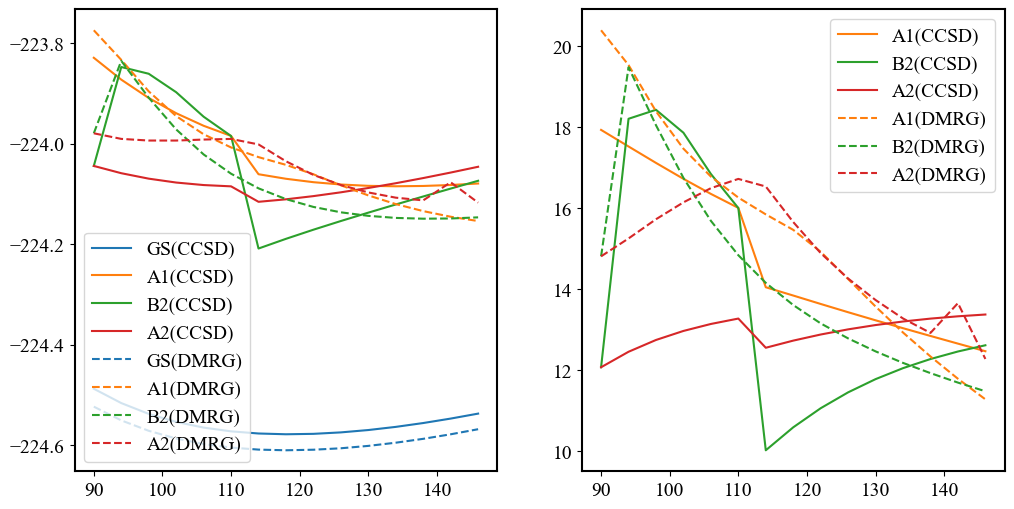

In [28]:
import matplotlib.pyplot as plt

fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,6))

ax1.plot(theta[idx], e0_ccsd[idx], label='GS(CCSD)', color='C0')
ax1.plot(theta[idx], e0_ccsd[idx]+ip_a1_ccsd[idx], label='A1(CCSD)', color='C1')
ax1.plot(theta[idx], e0_ccsd[idx]+ip_b2_ccsd[idx], label='B2(CCSD)', color='C2')
ax1.plot(theta[idx], e0_ccsd[idx]+ip_a2_ccsd[idx], label='A2(CCSD)', color='C3')

ax1.plot(theta[idx], e0_dmrg_a1[idx], label='GS(DMRG)', color='C0', ls='--')
ax1.plot(theta[idx], ei_dmrg_a1[idx], label='A1(DMRG)', color='C1', ls='--')
ax1.plot(theta[idx], ei_dmrg_b2[idx], label='B2(DMRG)', color='C2', ls='--')
ax1.plot(theta[idx], ei_dmrg_a2[idx], label='A2(DMRG)', color='C3', ls='--')

ax2.plot(theta[idx], (ip_a1_ccsd[idx])*au2ev, label='A1(CCSD)', color='C1')
ax2.plot(theta[idx], (ip_b2_ccsd[idx])*au2ev, label='B2(CCSD)', color='C2')
ax2.plot(theta[idx], (ip_a2_ccsd[idx])*au2ev, label='A2(CCSD)', color='C3')

ax2.plot(theta[idx], (ei_dmrg_a1[idx] - e0_dmrg_a1[idx])*au2ev, label='A1(DMRG)', color='C1', ls='--')
ax2.plot(theta[idx], (ei_dmrg_b2[idx] - e0_dmrg_a1[idx])*au2ev, label='B2(DMRG)', color='C2', ls='--')
ax2.plot(theta[idx], (ei_dmrg_a2[idx] - e0_dmrg_a1[idx])*au2ev, label='A2(DMRG)', color='C3', ls='--')

ax1.set_ylabel('')

ax1.legend()
ax2.legend()